In [1]:
from google.colab import files
uploaded = files.upload()

Saving disney_plus_titles_cleaned(2) (1).xlsx to disney_plus_titles_cleaned(2) (1).xlsx


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_excel("disney_plus_titles_cleaned(2) (1).xlsx")

df.head()

,title,type,release_year,date_added,country,rating,genre,duration_minutes
0,Duck the Halls: A Mickey Mouse Christmas Special,Movie,2016,2021-11-26,Unknown,TV-G,"Animation, Family",23.0
1,Ernest Saves Christmas,Movie,1988,2021-11-26,Unknown,PG,Comedy,91.0
2,Ice Age: A Mammoth Christmas,Movie,2011,2021-11-26,United States,TV-G,"Animation, Comedy, Family",23.0
3,The Queen Family Singalong,Movie,2021,2021-11-26,Unknown,TV-PG,Musical,41.0
4,The Beatles: Get Back,TV Show,2021,2021-11-25,Unknown,Not Rated,"Docuseries, Historical, Music",NaN


In [4]:
df.shape

(1447, 8)

In [8]:
df.columns

Index(['title', 'type', 'release_year', 'date_added', 'country', 'rating',
       'genre', 'duration_minutes'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1447 entries, 0 to 1446
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   title             1447 non-null   object 
 1   type              1447 non-null   object 
 2   release_year      1447 non-null   int64  
 3   date_added        1447 non-null   object 
 4   country           1447 non-null   object 
 5   rating            1447 non-null   object 
 6   genre             1447 non-null   object 
 7   duration_minutes  1052 non-null   float64
dtypes: float64(1), int64(1), object(6)
memory usage: 90.6+ KB


In [9]:
df.isnull().sum()

,0
title,0
type,0
release_year,0
date_added,0
country,0
rating,0
genre,0
duration_minutes,395


In [10]:
df.describe()

,release_year,duration_minutes
count,1447.000000,1052.000000
mean,2003.071873,71.910646
std,21.877923,40.595585
min,1928.000000,1.000000
25%,1999.000000,44.000000
50%,2011.000000,85.000000
75%,2018.000000,98.000000
max,2021.000000,183.000000


In [11]:
movies = df[df['type'].str.lower() == 'movie'].copy()

movies.head()

,title,type,release_year,date_added,country,rating,genre,duration_minutes
0,Duck the Halls: A Mickey Mouse Christmas Special,Movie,2016,2021-11-26,Unknown,TV-G,"Animation, Family",23.0
1,Ernest Saves Christmas,Movie,1988,2021-11-26,Unknown,PG,Comedy,91.0
2,Ice Age: A Mammoth Christmas,Movie,2011,2021-11-26,United States,TV-G,"Animation, Comedy, Family",23.0
3,The Queen Family Singalong,Movie,2021,2021-11-26,Unknown,TV-PG,Musical,41.0
5,Becoming Cousteau,Movie,2021,2021-11-24,United States,PG-13,"Biographical, Documentary",94.0


In [12]:
movies.shape

(1052, 8)

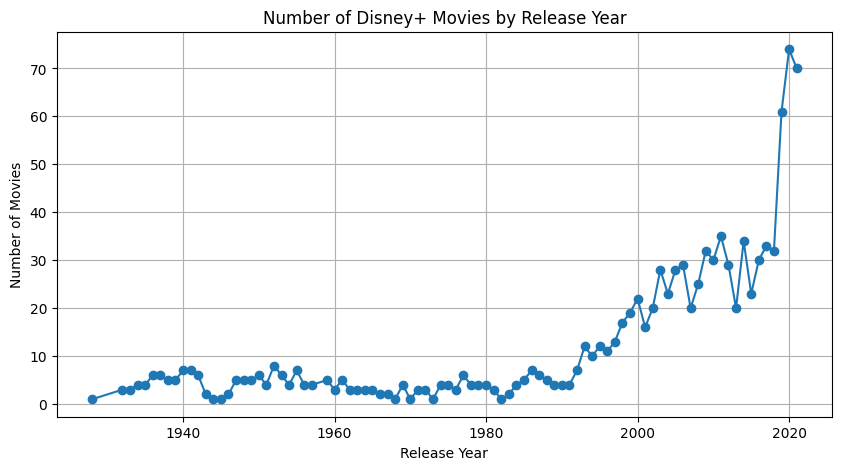

In [14]:
year_count = movies['release_year'].value_counts().sort_index()
plt.figure(figsize=(10,5))
plt.plot(year_count.index,year_count.values,marker='o')
plt.title('Number of Disney+ Movies by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Movies')
plt.grid(True)
plt.show()

In [15]:
genre_count = (
    movies['genre']
    .dropna()
    .str.split(',')
    .explode()
    .str.strip()
    .value_counts()
)

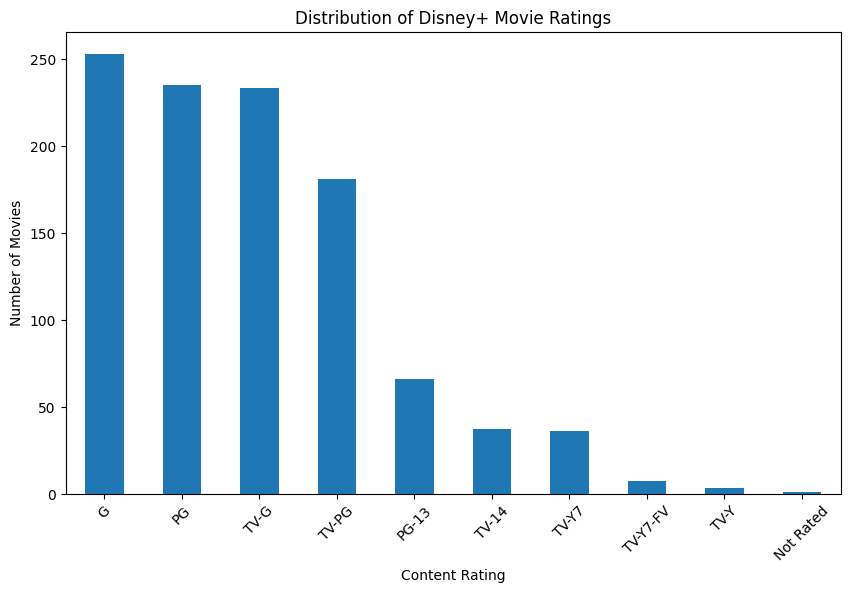

In [20]:
rating_count = movies['rating'].value_counts()

plt.figure(figsize=(10,6))

rating_count.plot(kind='bar')

plt.title('Distribution of Disney+ Movie Ratings')
plt.xlabel('Content Rating')
plt.ylabel('Number of Movies')

plt.xticks(rotation=45)

plt.show()

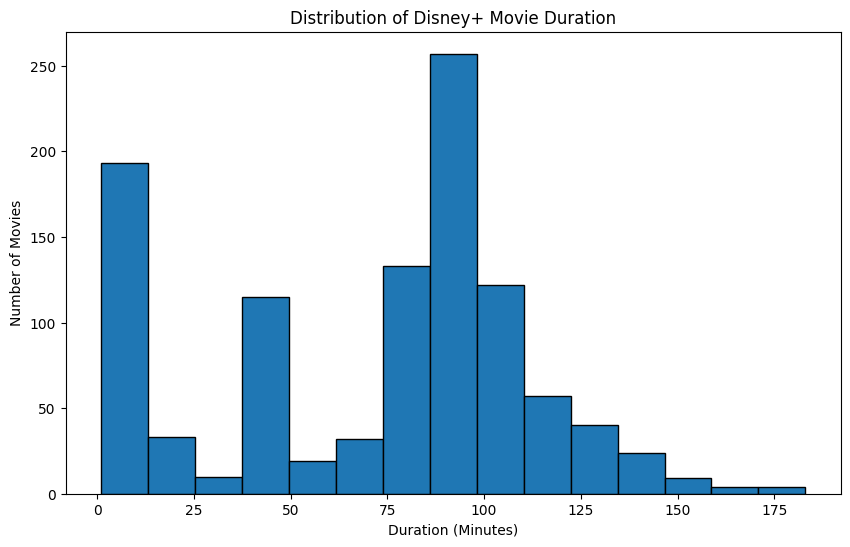

In [21]:
plt.figure(figsize=(10,6))

plt.hist(movies['duration_minutes'].dropna(),
         bins=15,
         edgecolor='black')

plt.title('Distribution of Disney+ Movie Duration')
plt.xlabel('Duration (Minutes)')
plt.ylabel('Number of Movies')

plt.show()

In [24]:
country_count = (
    movies['country']
    .dropna()
    .str.split(',')
    .explode()
    .str.strip()
    .value_counts()
    .head(10)
)

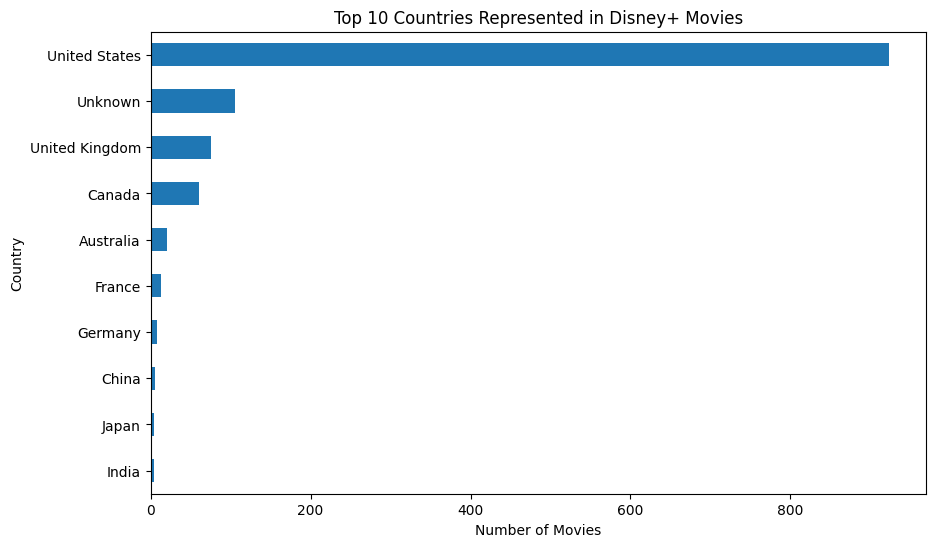

In [25]:
plt.figure(figsize=(10,6))

country_count.sort_values().plot(kind='barh')

plt.title('Top 10 Countries Represented in Disney+ Movies')
plt.xlabel('Number of Movies')
plt.ylabel('Country')

plt.show()

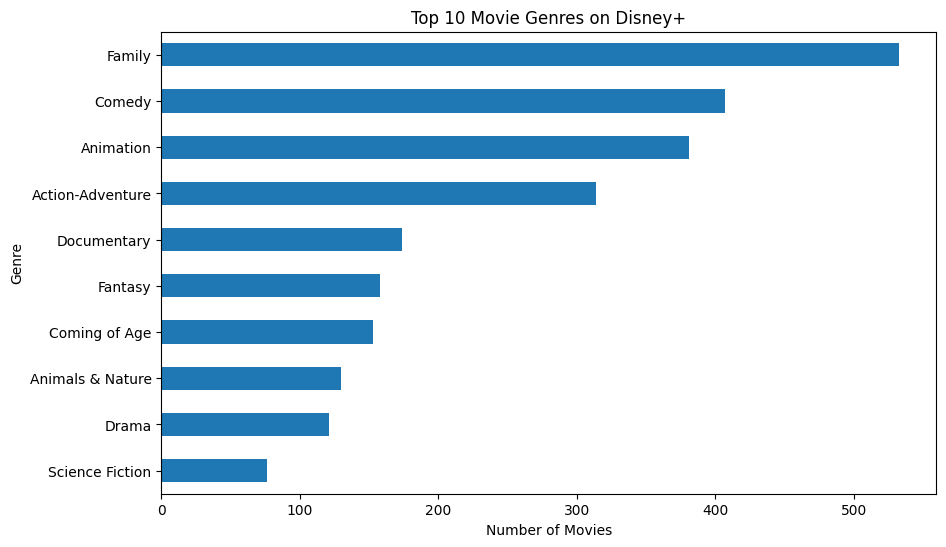

In [26]:
top_genres = genre_count.head(10)

plt.figure(figsize=(10,6))

top_genres.sort_values().plot(kind='barh')

plt.title('Top 10 Movie Genres on Disney+')
plt.xlabel('Number of Movies')
plt.ylabel('Genre')

plt.show()

In [27]:
genre_duration = (
    movies[['genre', 'duration_minutes']]
    .dropna()
    .assign(genre=lambda x: x['genre'].str.split(','))
    .explode('genre')
)

genre_duration['genre'] = genre_duration['genre'].str.strip()

avg_duration = (
    genre_duration
    .groupby('genre')['duration_minutes']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

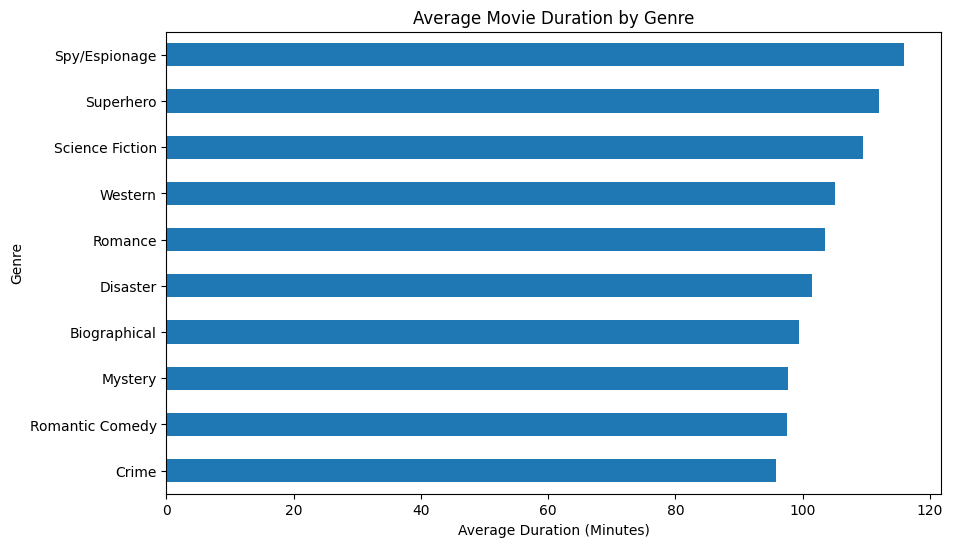

In [28]:
plt.figure(figsize=(10,6))

avg_duration.sort_values().plot(kind='barh')

plt.title('Average Movie Duration by Genre')
plt.xlabel('Average Duration (Minutes)')
plt.ylabel('Genre')

plt.show()